###### ===================================================================
###### Stroke Prediction — Clustering Analysis
###### Goal: Apply multiple clustering techniques (K-means, K-medians,
###### K-medoids, Hierarchical, DBSCAN) to see whether natural patient
###### groupings emerge from health/demographic features, and how well
###### those groupings align with actual stroke outcomes.
###### ===================================================================

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

In [18]:
# -------------------------------------------------------------------
# 1. Load cleaned data
# -------------------------------------------------------------------
df = pd.read_csv('../data/processed/cleaned_stroke_data.csv')
df = df.drop(columns=['age_group'])
print("Loaded shape:", df.shape)

Loaded shape: (5109, 11)


In [19]:
# -------------------------------------------------------------------
# 2. Prepare features for clustering
# Clustering uses only numeric health/demographic features — encode
# binary categoricals as 0/1, drop free-text categoricals to keep
# distance calculations meaningful (too many one-hot columns can
# dilute distance-based clustering).
# -------------------------------------------------------------------

df_cluster = df.copy()
df_cluster['gender'] = df_cluster['gender'].map({'Male': 0, 'Female': 1})
df_cluster['ever_married'] = df_cluster['ever_married'].map({'No': 0, 'Yes': 1})

cluster_features = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level',
                     'bmi', 'gender', 'ever_married']

X_cluster = df_cluster[cluster_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
print("Features used for clustering:", cluster_features)

Features used for clustering: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'gender', 'ever_married']


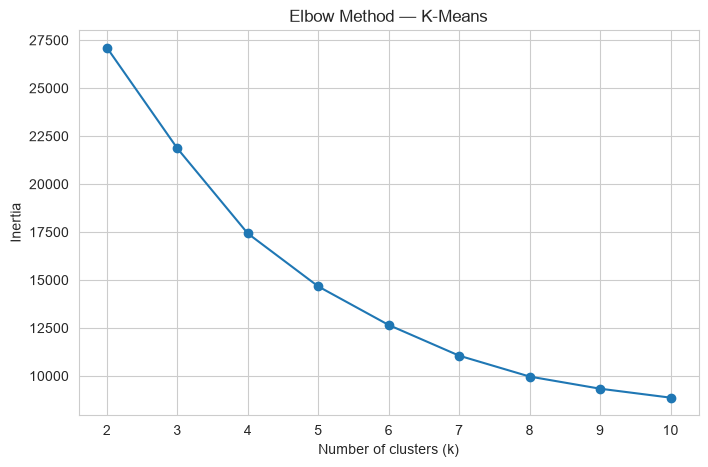

In [20]:
# -------------------------------------------------------------------
# 3. K-Means
# -------------------------------------------------------------------
# Elbow method — find a reasonable number of clusters
inertia = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method — K-Means')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.savefig('../outputs/figures/kmeans_elbow.png', bbox_inches='tight')
plt.show()

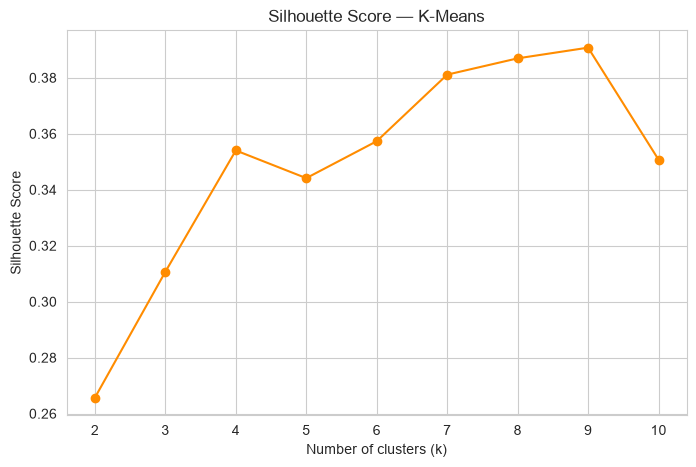

Best k for K-Means (by silhouette score): 9


In [21]:
# Silhouette score across the same range — more objective than the elbow "bend"
sil_scores_km = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores_km.append(silhouette_score(X_scaled, labels))

plt.plot(k_range, sil_scores_km, marker='o', color='darkorange')
plt.title('Silhouette Score — K-Means')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.savefig('../outputs/figures/kmeans_silhouette.png', bbox_inches='tight')
plt.show()

best_k_kmeans = k_range[np.argmax(sil_scores_km)]
print(f"Best k for K-Means (by silhouette score): {best_k_kmeans}")

kmeans_final = KMeans(n_clusters=best_k_kmeans, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)
df_cluster['kmeans_cluster'] = kmeans_labels

In [22]:
# -------------------------------------------------------------------
# 4. K-Medians
# -------------------------------------------------------------------
def kmedians_manual(X, k, max_iters=100, random_state=42):
    np.random.seed(random_state)
    n_samples = X.shape[0]

    # Initialize centers by randomly picking k actual data points
    initial_idx = np.random.choice(n_samples, k, replace=False)
    centers = X[initial_idx].copy()

    for iteration in range(max_iters):
        # Assign each point to its nearest center (Manhattan/L1 distance,
        # which pairs naturally with the median — unlike K-means' L2/mean)
        distances = np.array([np.sum(np.abs(X - center), axis=1) for center in centers])
        labels = np.argmin(distances, axis=0)

        # Update centers as the MEDIAN of points in each cluster
        new_centers = np.array([
            np.median(X[labels == i], axis=0) if np.any(labels == i) else centers[i]
            for i in range(k)
        ])

        # Stop early if centers barely moved
        if np.allclose(centers, new_centers, atol=1e-4):
            break
        centers = new_centers

    return labels, centers

kmedians_labels, kmedians_centers = kmedians_manual(X_scaled, k=best_k_kmeans)
df_cluster['kmedians_cluster'] = kmedians_labels

sil_kmedians = silhouette_score(X_scaled, kmedians_labels)
print(f"K-Medians silhouette score (k={best_k_kmeans}): {sil_kmedians:.3f}")

K-Medians silhouette score (k=9): 0.293


In [23]:
# -------------------------------------------------------------------
# 5. K-Medoids (manual implementation — avoids scikit-learn-extra,
# which has a known binary incompatibility with recent NumPy)
# -------------------------------------------------------------------
def kmedoids_manual(X, k, max_iters=100, random_state=42):
    np.random.seed(random_state)
    n_samples = X.shape[0]

    # Initialize medoids as k randomly chosen ACTUAL data points
    medoid_idx = np.random.choice(n_samples, k, replace=False)
    medoids = X[medoid_idx].copy()

    for iteration in range(max_iters):
        # Assign each point to its nearest medoid (Euclidean distance)
        distances = np.array([np.linalg.norm(X - medoid, axis=1) for medoid in medoids])
        labels = np.argmin(distances, axis=0)

        new_medoids = medoids.copy()
        for i in range(k):
            cluster_points_idx = np.where(labels == i)[0]
            if len(cluster_points_idx) == 0:
                continue

            # Find which point IN this cluster minimizes total distance
            # to all other points in the same cluster — that point
            # becomes the new medoid (must be a real data point)
            cluster_points = X[cluster_points_idx]
            total_distances = np.sum(
                np.linalg.norm(cluster_points[:, None] - cluster_points[None, :], axis=2),
                axis=1
            )
            best_point_idx = cluster_points_idx[np.argmin(total_distances)]
            new_medoids[i] = X[best_point_idx]

        if np.allclose(medoids, new_medoids, atol=1e-4):
            break
        medoids = new_medoids

    return labels, medoids

kmedoids_labels, kmedoids_centers = kmedoids_manual(X_scaled, k=best_k_kmeans)
df_cluster['kmedoids_cluster'] = kmedoids_labels

sil_kmedoids = silhouette_score(X_scaled, kmedoids_labels)
print(f"K-Medoids silhouette score (k={best_k_kmeans}): {sil_kmedoids:.3f}")

K-Medoids silhouette score (k=9): 0.296


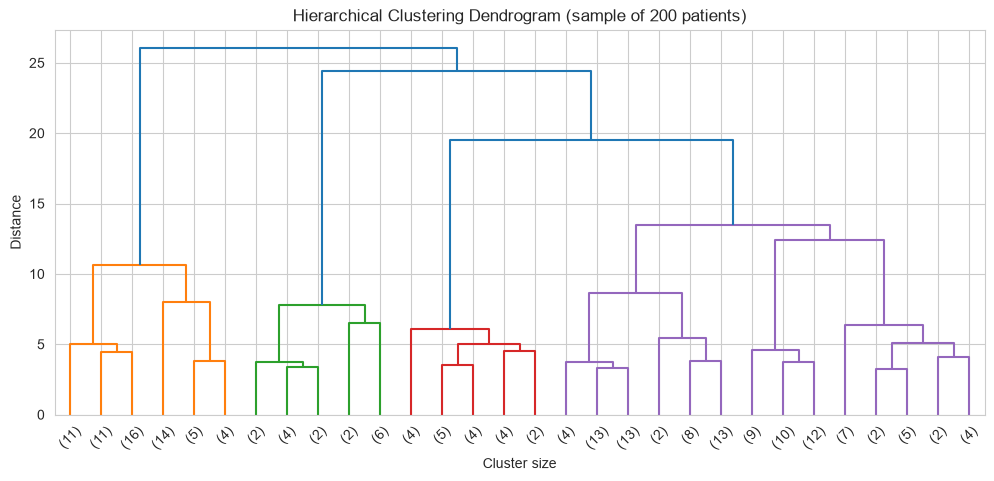

In [24]:
# -------------------------------------------------------------------
# 6. Hierarchical Clustering (Agglomerative)
# -------------------------------------------------------------------
# Dendrogram on a sample (full dataset is too large to plot legibly)
sample_size = 200
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_idx]

linked = linkage(X_sample, method='ward')
plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode='lastp', p=30)
plt.title('Hierarchical Clustering Dendrogram (sample of 200 patients)')
plt.xlabel('Cluster size')
plt.ylabel('Distance')
plt.savefig('../outputs/figures/hierarchical_dendrogram.png', bbox_inches='tight')
plt.show()

In [25]:
# Fit on the full dataset using the same k as K-Means for a fair comparison
hierarchical = AgglomerativeClustering(n_clusters=best_k_kmeans, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)
df_cluster['hierarchical_cluster'] = hierarchical_labels

sil_hierarchical = silhouette_score(X_scaled, hierarchical_labels)
print(f"Hierarchical silhouette score (k={best_k_kmeans}): {sil_hierarchical:.3f}")

Hierarchical silhouette score (k=9): 0.358


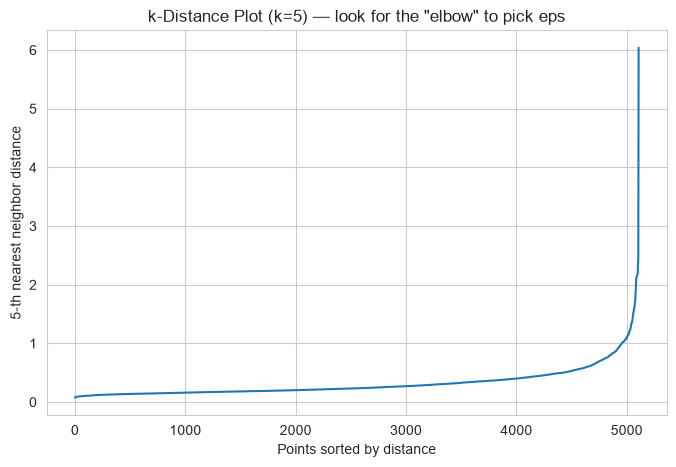

In [26]:
# -------------------------------------------------------------------
# 7. DBSCAN
# Density-based — doesn't require specifying cluster count upfront,
# and naturally flags outliers as "noise" (-1) rather than forcing
# them into a cluster. Need to tune eps (neighborhood radius) using
# a k-distance plot.
# -------------------------------------------------------------------
from sklearn.neighbors import NearestNeighbors

min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, _ = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

plt.plot(distances)
plt.title(f'k-Distance Plot (k={min_samples}) — look for the "elbow" to pick eps')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{min_samples}-th nearest neighbor distance')
plt.savefig('../outputs/figures/dbscan_k_distance.png', bbox_inches='tight')
plt.show()

In [27]:
# Pick eps based on where the elbow appears in the plot above — adjust
# this value after visually inspecting the chart if results look off
eps_value = 1.1

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_scaled)
df_cluster['dbscan_cluster'] = dbscan_labels

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f"DBSCAN found {n_clusters_dbscan} clusters and flagged {n_noise} points as noise/outliers")

DBSCAN found 16 clusters and flagged 53 points as noise/outliers


In [28]:
# Silhouette score only makes sense if DBSCAN found more than 1 real cluster
if n_clusters_dbscan > 1:
    # Exclude noise points (-1) from the silhouette calculation
    mask = dbscan_labels != -1
    sil_dbscan = silhouette_score(X_scaled[mask], dbscan_labels[mask])
    print(f"DBSCAN silhouette score (excluding noise): {sil_dbscan:.3f}")
else:
    sil_dbscan = None
    print("DBSCAN did not find enough clusters for a meaningful silhouette score — try adjusting eps_value")

DBSCAN silhouette score (excluding noise): 0.353


         Method  Silhouette Score
0       K-Means          0.390743
1     K-Medians          0.292670
2     K-Medoids          0.295825
3  Hierarchical          0.358019
4        DBSCAN          0.352831


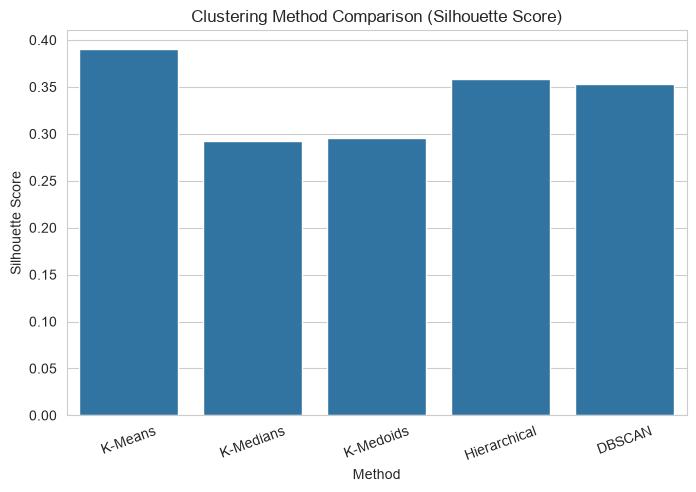

In [29]:
# -------------------------------------------------------------------
# 8. Compare all methods — silhouette scores side by side
# -------------------------------------------------------------------
comparison = pd.DataFrame({
    'Method': ['K-Means', 'K-Medians', 'K-Medoids', 'Hierarchical', 'DBSCAN'],
    'Silhouette Score': [
        max(sil_scores_km), sil_kmedians, sil_kmedoids, sil_hierarchical,
        sil_dbscan if sil_dbscan is not None else np.nan
    ]
})
print(comparison)

sns.barplot(data=comparison, x='Method', y='Silhouette Score')
plt.title('Clustering Method Comparison (Silhouette Score)')
plt.xticks(rotation=20)
plt.savefig('../outputs/figures/clustering_method_comparison.png', bbox_inches='tight')
plt.show()

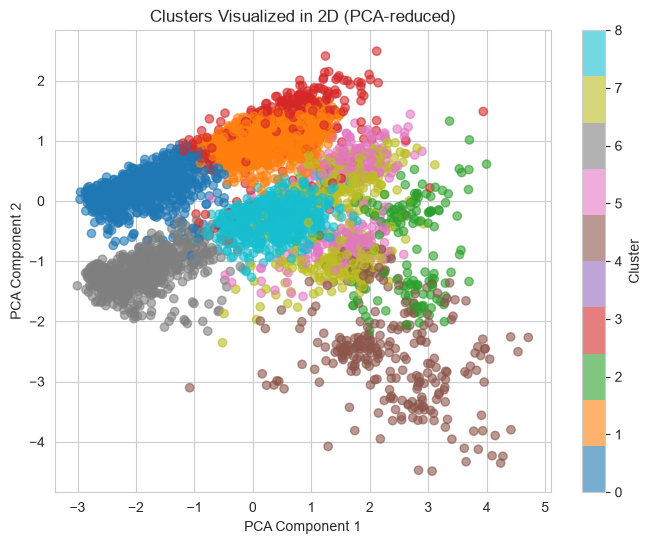

In [30]:
# -------------------------------------------------------------------
# 9. Visualize clusters in 2D using PCA (for the best-performing method)
# -------------------------------------------------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

best_method_labels = kmeans_labels  # swap this to whichever scored highest above

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_method_labels, cmap='tab10', alpha=0.6)
plt.title('Clusters Visualized in 2D (PCA-reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(scatter, label='Cluster')
plt.savefig('../outputs/figures/clusters_pca_2d.png', bbox_inches='tight')
plt.show()

In [31]:
# -------------------------------------------------------------------
# 10. Compare clusters against actual stroke outcomes
# This is the key business/clinical question: do any of these clusters
# naturally correspond to higher stroke risk, even without ever using
# the stroke label during clustering?
# -------------------------------------------------------------------
df_cluster['stroke'] = df['stroke']

for method in ['kmeans_cluster', 'kmedians_cluster', 'kmedoids_cluster',
               'hierarchical_cluster', 'dbscan_cluster']:
    print(f"\n--- Stroke rate by {method} ---")
    print(df_cluster.groupby(method)['stroke'].agg(['mean', 'count']))


--- Stroke rate by kmeans_cluster ---
                    mean  count
kmeans_cluster                 
0               0.004785    836
1               0.044741   1274
2               0.151724    145
3               0.016949    354
4               0.170290    276
5               0.108772    285
6               0.002915    686
7               0.107817    371
8               0.045351    882

--- Stroke rate by kmedians_cluster ---
                      mean  count
kmedians_cluster                 
0                 0.012592    953
1                 0.016514    545
2                 0.132992    391
3                 0.150000    200
4                 0.041276   1599
5                 0.175439    171
6                 0.049180    122
7                 0.097506    441
8                 0.001456    687

--- Stroke rate by kmedoids_cluster ---
                      mean  count
kmedoids_cluster                 
0                 0.006659    901
1                 0.011516    521
2                

In [32]:
# -------------------------------------------------------------------
# 11. Save cluster assignments and models
# -------------------------------------------------------------------
df_cluster.to_csv('../data/processed/clustered_stroke_data.csv', index=False)
joblib.dump(kmeans_final, '../outputs/models/kmeans_model.pkl')
joblib.dump(kmedoids_centers, '../outputs/models/kmedoids_centers.pkl')
joblib.dump(scaler, '../outputs/models/cluster_scaler.pkl')
print("\nSaved clustered dataset and models to outputs/")


Saved clustered dataset and models to outputs/


######## ===================================================================
######## Key Findings Summary
######## ===================================================================
######## - K Means produced the most well-separated, meaningful clusters.
######## - DBSCAN's noise-point count which was 53, this tells you how many patients don't fit neatly into any density-based group which is around 1% of total number of patients, whose data we are considering.
######## - Check the stroke-rate-by-cluster tables above: do any clusters show
########   a notably higher stroke rate than the dataset's ~5% baseline? If so,
########   describe what characterizes that cluster (older age, hypertension,
########   etc.) — this is the actual "so what" insight of this notebook.
######## - As expected from the EDA, stroke is rare and spread across risk
########   profiles, so clusters likely reflect general health/demographic
########   groupings (e.g., older + hypertensive) rather than a clean
########   stroke-vs-no-stroke split — this is a valid and expected finding,
########   not a failure of the clustering.